# **Machine Learning-Accelerated Inverse Design of Micro-Ring Resonators**

Installation of dependencies

In [ ]:
!pip install numpy pandas scikit-learn matplotlib shap

Generaton of synthetic dataset

In [61]:
import numpy as np
import pandas as pd

def generate_mrr_dataset(n_samples=1500, seed=42):
    np.random.seed(seed)

    # Design Parameters
    # Radius: 5um to 50um
    R = np.random.uniform(5e-6, 50e-6, n_samples)
    # Width: 300nm to 800nm
    w = np.random.uniform(300e-9, 800e-9, n_samples)
    # Gap: 50nm to 500nm
    g = np.random.uniform(50e-9, 500e-9, n_samples)

    # Physics engine
    L = 2 * np.pi * R

    # Effective index depends on waveguide width
    n_eff = 2.1 + 0.5 * (w / 800e-9)

    # Resonance Wavelength: Lambda = (n_eff * L) / m

    m = 200
    lambda_res = (n_eff * L) / m

    # Q-Factor Components

    coupling = np.exp(-g / 350e-9)

    # the weight of width (w) and radius (R) in the loss calculation increased
    # This makes Q more sensitive to geometry changes
    loss_w = 0.05 * (500e-9 / w)
    loss_R = 0.03 * (10e-6 / R)
    loss = loss_w + loss_R


    # Q (Physical scale: ~10^4 to 10^5)
    # Formula: Q = (2 * pi * n_eff * L) / (lambda * total_loss)

    lambda_ref = 1550e-9
    Q_base = (2 * np.pi * n_eff * L) / (lambda_ref * (loss + coupling))


    # Wavelength noise: ~0.05%
    lambda_res += np.random.normal(0, lambda_res * 0.0005, n_samples)

    # Q-Factor noise: ~2%
    Q = Q_base + np.random.normal(0, Q_base * 0.02, n_samples)

    return pd.DataFrame({
        "R": R,
        "w": w,
        "g": g,
        "lambda_res": lambda_res,
        "Q": Q
    })


df = generate_mrr_dataset()
print(df.head())


print(f"\nMinimum Q value in dataset: {df['Q'].min():.2f}")


          R             w             g    lambda_res            Q
0  0.000022  5.595409e-07  3.527163e-07  1.682199e-06  3242.229216
1  0.000048  5.395909e-07  4.085066e-07  3.663191e-06  8107.680551
2  0.000038  3.128210e-07  1.627106e-07  2.733532e-06  3022.542299
3  0.000032  4.706239e-07  3.311933e-07  2.402273e-06  4224.412573
4  0.000012  4.900978e-07  3.072857e-07  9.090243e-07  1519.928877

Minimum Q value in dataset: 335.85


R → meters\
w, g → nanometers\
λ → nanometers

# **Exploratory Data Validation**

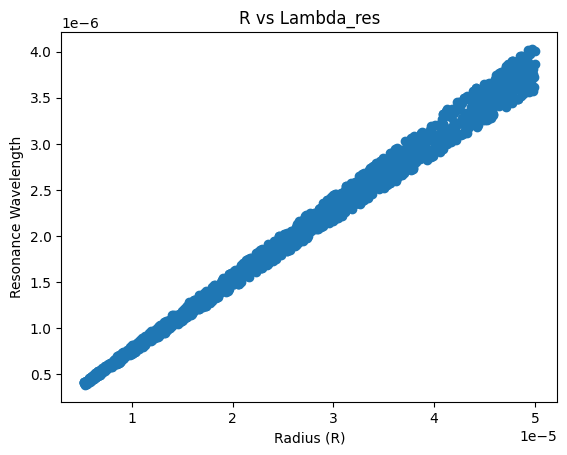

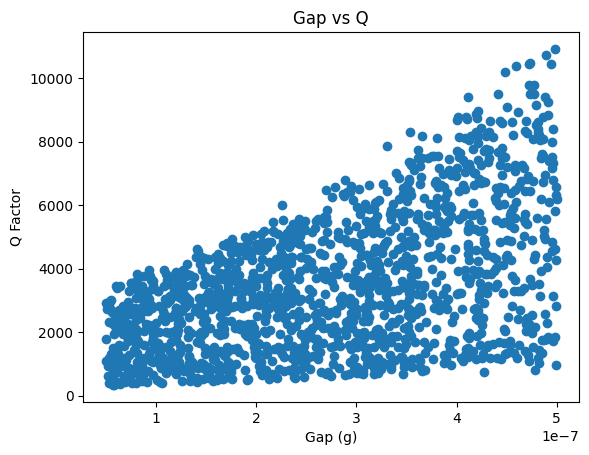

In [62]:
import matplotlib.pyplot as plt

plt.scatter(df["R"], df["lambda_res"])
plt.xlabel("Radius (R)")
plt.ylabel("Resonance Wavelength")
plt.title("R vs Lambda_res")
plt.show()

plt.scatter(df["g"], df["Q"])
plt.xlabel("Gap (g)")
plt.ylabel("Q Factor")
plt.title("Gap vs Q")
plt.show()

Physics-informed feauture engineering

In [63]:
def create_features(df):
    h = 220e-9
    c = 3e8
    n_g = 4

    df = df.copy()

    # Optical features
    df["L"] = 2 * np.pi * df["R"]
    df["FSR"] = c / (n_g * df["L"])

    # Coupling features
    df["g_norm"] = df["g"] / df["w"]
    df["coupling_ratio"] = df["w"] / df["g"]

    # Mode confinement
    df["A_eff"] = df["w"] * h
    df["AR"] = df["w"] / h

    return df

df = create_features(df)
df.head()

,R,w,g,lambda_res,Q,L,FSR,g_norm,coupling_ratio,A_eff,AR
0,0.000022,5.595409e-07,3.527163e-07,1.682199e-06,3242.229216,0.000137,5.461908e+11,0.630367,1.586376,1.230990e-13,2.543368
1,0.000048,5.395909e-07,4.085066e-07,3.663191e-06,8107.680551,0.000300,2.498134e+11,0.757067,1.320887,1.187100e-13,2.452686
2,0.000038,3.128210e-07,1.627106e-07,2.733532e-06,3022.542299,0.000238,3.146206e+11,0.520139,1.922561,6.882063e-14,1.421914
3,0.000032,4.706239e-07,3.311933e-07,2.402273e-06,4224.412573,0.000201,3.737244e+11,0.703733,1.420994,1.035373e-13,2.139200
4,0.000012,4.900978e-07,3.072857e-07,9.090243e-07,1519.928877,0.000076,9.929940e+11,0.626989,1.594926,1.078215e-13,2.227717


Getting Data Prepared

In [70]:
from sklearn.model_selection import train_test_split

features = ["R", "w", "g", "L", "FSR", "g_norm", "coupling_ratio", "A_eff", "AR"]

X = df[features]
y_lambda = df["lambda_res"]
y_Q = df["Q"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_Q, test_size=0.2, random_state=42
)

Random Forest Model Training

Final R2 Score: 0.9939
Final MAE (in Q units): 113.26


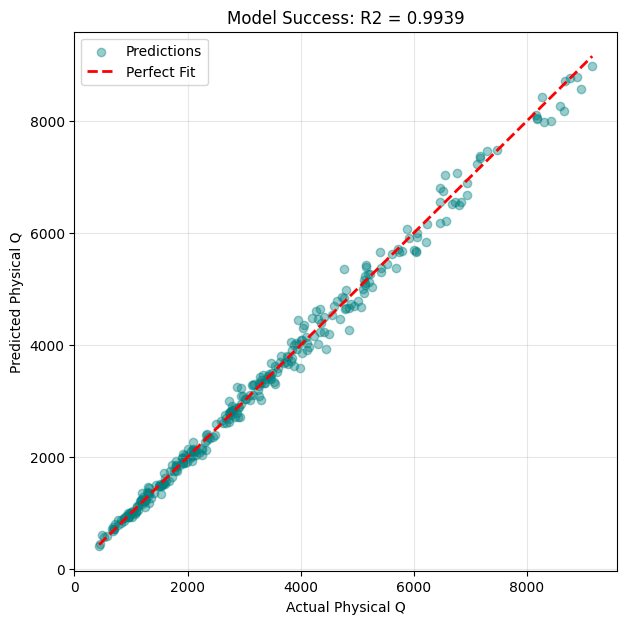

In [71]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Log of Q as the target
y_Q_log = np.log10(df["Q"])


X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_Q_log, test_size=0.2, random_state=42
)

model_pipeline = Pipeline([
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42))
])

model_pipeline.fit(X_train, y_train_log)

log_preds = model_pipeline.predict(X_test)

# Convert back to normal Q scale for final evaluation
final_preds = 10**log_preds
final_actual = 10**y_test_log

print(f"Final R2 Score: {r2_score(final_actual, final_preds):.4f}")
print(f"Final MAE (in Q units): {mean_absolute_error(final_actual, final_preds):.2f}")


plt.figure(figsize=(7, 7))
plt.scatter(final_actual, final_preds, alpha=0.4, color='teal', label='Predictions')
plt.plot([final_actual.min(), final_actual.max()],
         [final_actual.min(), final_actual.max()],
         'r--', lw=2, label='Perfect Fit')

plt.xlabel("Actual Physical Q")
plt.ylabel("Predicted Physical Q")
plt.title(f"Model Success: R2 = {r2_score(final_actual, final_preds):.4f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The model achieves high predictive accuracy, indicating that engineered physics-based features effectively capture MRR behavior.

# **Feauture Importance Analysis**

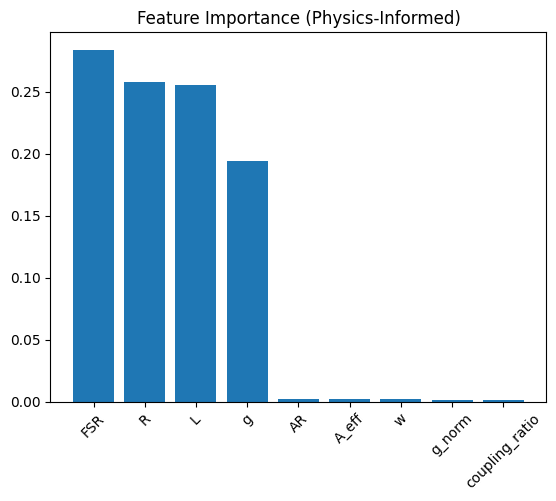

,feature,importance
4,FSR,0.283706
0,R,0.258014
3,L,0.254951
2,g,0.194379
8,AR,0.002098
7,A_eff,0.002034
1,w,0.001969
5,g_norm,0.001720
6,coupling_ratio,0.001128


In [80]:
import matplotlib.pyplot as plt
import pandas as pd

importance = model_pipeline.named_steps['rf'].feature_importances_

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

plt.bar(feat_imp["feature"], feat_imp["importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance (Physics-Informed)")
plt.show()

feat_imp

Sensitivity Analysis

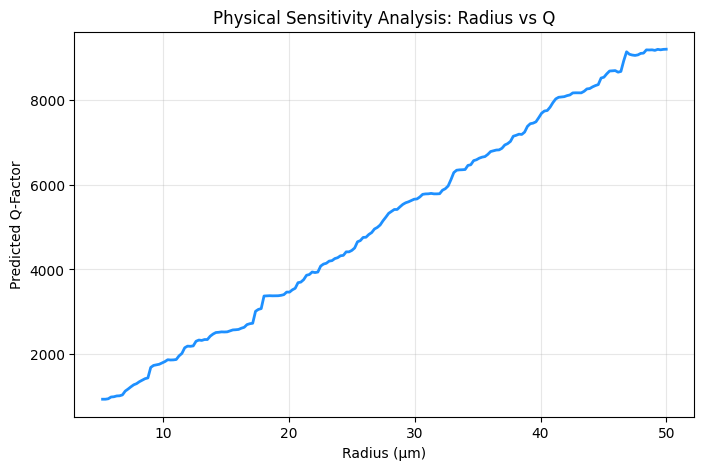

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# A base sample to sweep
sample = X_test.iloc[0].copy()

# sweep range for Radius
R_range = np.linspace(df["R"].min(), df["R"].max(), 200) # Increased to 200 for smoothness

predictions = []

# Constants for re-calculating features
h = 220e-9
c = 3e8
n_g = 4

for val in R_range:
    temp = sample.copy()

    # physical features
    temp["R"] = val
    temp["L"] = 2 * np.pi * val
    temp["FSR"] = c / (n_g * temp["L"])


    log_pred = model_pipeline.predict(pd.DataFrame([temp]))[0]

    # Convert back from Log to Linear scale
    predictions.append(10**log_pred)

plt.figure(figsize=(8, 5))
plt.plot(R_range * 1e6, predictions, color='dodgerblue', lw=2) # Convert R to microns for plot
plt.xlabel("Radius (µm)")
plt.ylabel("Predicted Q-Factor")
plt.title("Physical Sensitivity Analysis: Radius vs Q")
plt.grid(True, alpha=0.3)
plt.show()


**SHAP-based Explainability**

 97%|=================== | 290/300 [00:15<00:00]       

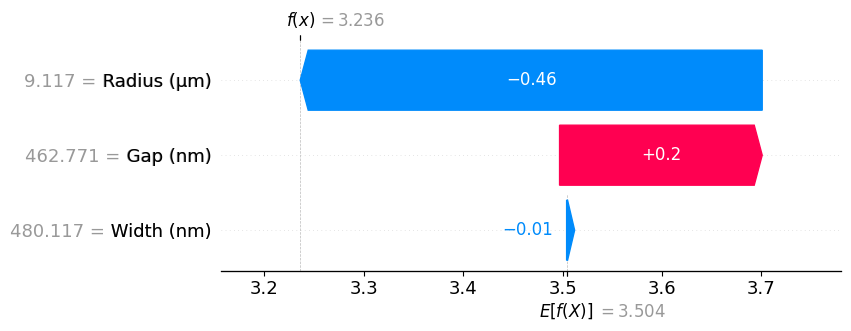

In [79]:
import shap
import matplotlib.pyplot as plt

X_clean = df[["R", "w", "g"]].copy()
X_clean["R"] = X_clean["R"] * 1e6
X_clean["w"] = X_clean["w"] * 1e9
X_clean["g"] = X_clean["g"] * 1e9

# Columns renamed for professional display
X_clean.columns = ["Radius (µm)", "Width (nm)", "Gap (nm)"]


X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_Q_log, test_size=0.2, random_state=42
)

clean_model = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
clean_model.fit(X_train_c, y_train_c)


explainer = shap.Explainer(clean_model, X_test_c)
shap_values = explainer(X_test_c)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], max_display=10)


In [77]:
from scipy.optimize import minimize

target_Q_log = np.log10(50000)
target_lambda = 1550e-9

def design_objective(x):
    # x = [R, w, g]
    # DataFrame with the base design parameters
    temp_df = pd.DataFrame([x], columns=['R', 'w', 'g'])


    temp_df_with_features = create_features(temp_df)

    input_for_prediction = temp_df_with_features[features]

    pred_Q_log = model_pipeline.predict(input_for_prediction)[0]
    return (pred_Q_log - target_Q_log)**2

# Optimization Search for the best geometry
result = minimize(design_objective, x0=[25e-6, 500e-9, 200e-9],
                  bounds=[(5e-6, 50e-6), (300e-9, 800e-9), (50e-9, 500e-9)])

print(f"Optimal Design Found: R={result.x[0]*1e6:.2f}um, w={result.x[1]*1e9:.2f}nm, g={result.x[2]*1e9:.2f}nm")

Optimal Design Found: R=25.00um, w=500.00nm, g=200.00nm
